In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K = 1 | Précision : 100.00%
K = 2 | Précision : 100.00%
K = 3 | Précision : 100.00%
K = 4 | Précision : 100.00%
K = 5 | Précision : 100.00%

Le nouveau fruit a été classé comme : Apple


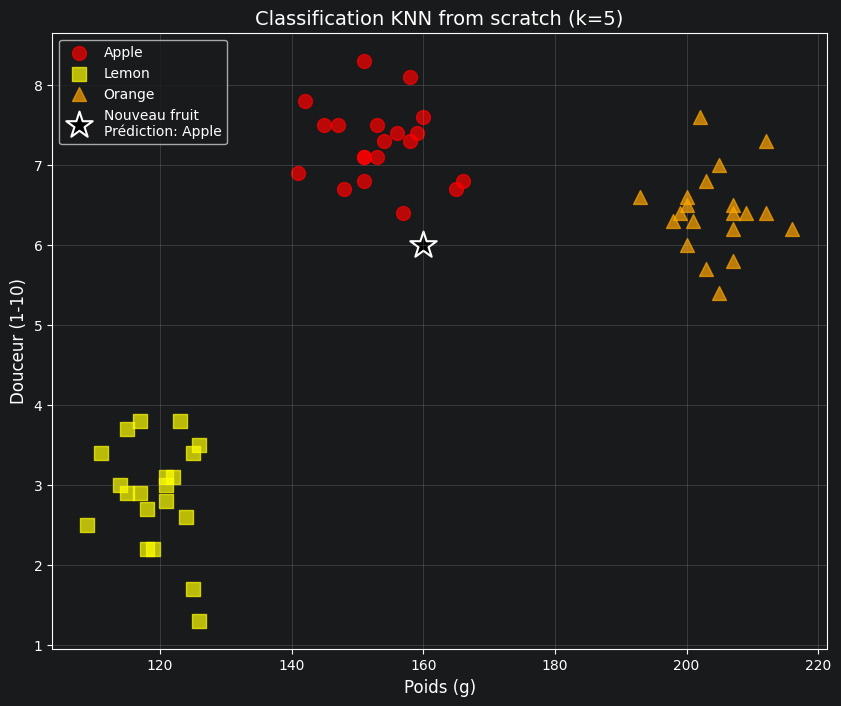

K = 1 | Erreur Moyenne (MSE) : 0.3075
K = 2 | Erreur Moyenne (MSE) : 0.4220
K = 3 | Erreur Moyenne (MSE) : 0.4370
K = 4 | Erreur Moyenne (MSE) : 0.4657
K = 5 | Erreur Moyenne (MSE) : 0.4701
K = 6 | Erreur Moyenne (MSE) : 0.3790
K = 7 | Erreur Moyenne (MSE) : 0.4446
K = 8 | Erreur Moyenne (MSE) : 0.4870
K = 9 | Erreur Moyenne (MSE) : 0.5149
K = 10 | Erreur Moyenne (MSE) : 0.5874


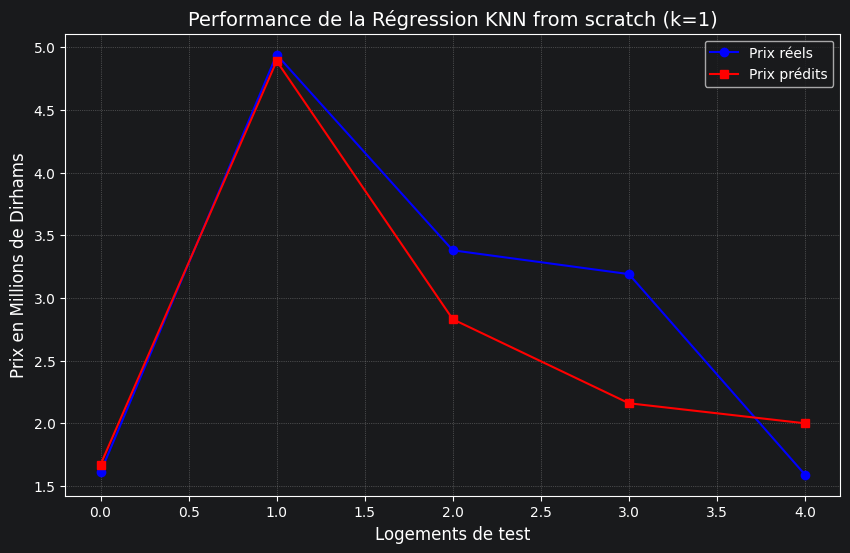

In [3]:
# Pour que les résultats soient toujours les mêmes à chaque exécution
np.random.seed(42)
#  DISTANCE EUCLIDIENNE
def distance_euclidienne(p, q):
    """
    Calcule la distance euclidienne entre deux points p et q.
    Chaque point est représenté par une liste ou un tableau de valeurs.
    """
    somme = 0
    for i in range(len(p)):
        somme += (p[i] - q[i]) ** 2
    return somme ** 0.5



# KNN POUR LA CLASSIFICATION
# GÉNÉRATION DE NOTRE PROPRE DATASET
# On crée 20 pommes, 20 citrons et 20 oranges avec des valeurs aléatoires autour de moyennes réalistes.

n_samples = 20

# Pommes : poids moyen ~155g, douceur moyenne ~7.4
apple_weight = np.random.normal(loc=155, scale=7, size=n_samples).astype(int)
apple_sweetness = np.round(np.random.normal(loc=7.4, scale=0.5, size=n_samples), 1)

# Citrons : poids moyen ~120g, douceur moyenne ~2.9
lemon_weight = np.random.normal(loc=120, scale=6, size=n_samples).astype(int)
lemon_sweetness = np.round(np.random.normal(loc=2.9, scale=0.6, size=n_samples), 1)

# Oranges : poids moyen ~205g, douceur moyenne ~6.4
orange_weight = np.random.normal(loc=205, scale=8, size=n_samples).astype(int)
orange_sweetness = np.round(np.random.normal(loc=6.4, scale=0.5, size=n_samples), 1)

# On assemble toutes les données dans un dictionnaire
data_classification = {
    'Weight (g)': np.concatenate([apple_weight, lemon_weight, orange_weight]),
    'Sweetness (1-10)': np.concatenate([apple_sweetness, lemon_sweetness, orange_sweetness]),
    'Fruit': (['Apple'] * n_samples) + (['Lemon'] * n_samples) + (['Orange'] * n_samples)
}

# Création du DataFrame
df_classification = pd.DataFrame(data_classification)

# On sépare les variables explicatives X et la cible y
X_class = df_classification[['Weight (g)', 'Sweetness (1-10)']].values
y_class = df_classification['Fruit'].values


# FONCTION KNN CLASSIFICATION

def knn_classification(X_train, y_train, x_nouveau, k):

    distances = []

    # Calcul de la distance entre x_nouveau et tous les points d'entraînement
    for i in range(len(X_train)):
        d = distance_euclidienne(X_train[i], x_nouveau)
        distances.append((d, y_train[i]))

    # Tri des distances de la plus petite à la plus grande
    distances.sort(key=lambda element: element[0])

    # Sélection des k plus proches voisins
    voisins = distances[:k]

    # Vote majoritaire
    votes = {}
    for voisin in voisins:
        etiquette = voisin[1]
        votes[etiquette] = votes.get(etiquette, 0) + 1

    # Classe finale = celle qui a le plus de votes
    classe_predite = max(votes, key=votes.get)

    return classe_predite


# FONCTION POUR CHOISIR LE MEILLEUR K EN CLASSIFICATION
def evaluer_k_classification(X, y, k_max=10):

    # Séparation simple : 80% entraînement / 20% test
    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    meilleur_k = 1
    meilleure_precision = 0

    for k in range(1, k_max + 1):
        correct = 0

        # On prédit chaque point du jeu de test
        for i in range(len(X_test)):
            prediction = knn_classification(X_train, y_train, X_test[i], k)
            if prediction == y_test[i]:
                correct += 1

        precision = correct / len(X_test)
        print(f"K = {k} | Précision : {precision:.2%}")

        # On garde le meilleur k
        if precision >= meilleure_precision:
            meilleure_precision = precision
            meilleur_k = k

    return meilleur_k

# ÉVALUATION ET PRÉDICTION
# Recherche de la meilleure valeur de k
k_class = evaluer_k_classification(X_class, y_class, k_max=5)

# Nouveau fruit à prédire
new_fruit = np.array([160, 6.0])

# Prédiction avec KNN
prediction_fruit = knn_classification(X_class, y_class, new_fruit, k_class)

print(f"\nLe nouveau fruit a été classé comme : {prediction_fruit}")

# REPRÉSENTATION GRAPHIQUE - CLASSIFICATION
plt.figure(figsize=(10, 8))

# Dictionnaires pour les couleurs et marqueurs
couleurs = {'Apple': 'red', 'Lemon': 'yellow', 'Orange': 'orange'}
marqueurs = {'Apple': 'o', 'Lemon': 's', 'Orange': '^'}

# Affichage des points du dataset
for fruit in df_classification['Fruit'].unique():
    masque = df_classification['Fruit'] == fruit
    plt.scatter(
        df_classification.loc[masque, 'Weight (g)'],
        df_classification.loc[masque, 'Sweetness (1-10)'],
        c=couleurs[fruit],
        marker=marqueurs[fruit],
        s=100,
        alpha=0.7,
        label=fruit
    )

# Affichage du nouveau fruit
plt.scatter(
    new_fruit[0], new_fruit[1],
    c='black',
    marker='*',
    s=400,
    label=f'Nouveau fruit\nPrédiction: {prediction_fruit}',
    edgecolors='white',
    linewidth=1.5
)

plt.xlabel('Poids (g)', fontsize=12)
plt.ylabel('Douceur (1-10)', fontsize=12)
plt.title(f'Classification KNN (k={k_class})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# KNN POUR LA RÉGRESSION

# GÉNÉRATION DE NOTRE PROPRE DATASET DE RÉGRESSION

# On crée 25 appartements avec :
# - surface
# - âge
# - prix (dépend de la surface et de l'âge avec un peu de bruit)

n_appartements = 25

# Génération aléatoire de la surface entre 25 et 150 m²
surface = np.random.randint(25, 151, size=n_appartements)

# Génération aléatoire de l'âge entre 1 et 40 ans
age = np.random.randint(1, 41, size=n_appartements)

# Formule simple pour générer le prix :
# Le prix augmente avec la surface et diminue avec l'âge
# + un bruit aléatoire pour rendre les données plus réalistes
bruit = np.random.normal(loc=0, scale=0.2, size=n_appartements)
prix = np.round(0.03 * surface - 0.02 * age + 0.8 + bruit, 2)

# On regroupe les données dans un dictionnaire
data_regression = {
    'Surface_m2': surface,
    'Age_ans': age,
    'Prix_M_dirham': prix
}

# DataFrame de régression
df_regression = pd.DataFrame(data_regression)

# Variables explicatives X et cible y
X_reg = df_regression[['Surface_m2', 'Age_ans']].values.tolist()
y_reg = df_regression['Prix_M_dirham'].values.tolist()


#FONCTION KNN RÉGRESSION
def knn_regression_from_scratch(X_train, y_train, x_nouveau, k):
    """
    Prédit une valeur numérique en utilisant KNN régression.
    La prédiction est la moyenne des valeurs des k voisins les plus proches.
    """
    distances = []

    # Calcul de la distance entre x_nouveau et tous les points d'entraînement
    for i in range(len(X_train)):
        d = distance_euclidienne(X_train[i], x_nouveau)
        distances.append((d, y_train[i]))

    # Tri par distance croissante
    distances.sort(key=lambda element: element[0])

    # On garde les k plus proches voisins
    voisins = distances[:k]

    # Moyenne des valeurs cibles des voisins
    somme = 0
    for voisin in voisins:
        somme += voisin[1]

    prediction = somme / k
    return prediction

#FONCTION POUR CHOISIR LE MEILLEUR K EN RÉGRESSION
def evaluer_k_regression(X, y, k_max=10):
    # Séparation 80% entraînement / 20% test
    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    meilleur_k = 1
    plus_petite_erreur = float('inf')

    for k in range(1, k_max + 1):
        somme_erreurs_au_carre = 0

        # On prédit chaque point de test
        for i in range(len(X_test)):
            prediction = knn_regression_from_scratch(X_train, y_train, X_test[i], k)
            erreur = (y_test[i] - prediction) ** 2
            somme_erreurs_au_carre += erreur

        mse = somme_erreurs_au_carre / len(X_test)
        print(f"K = {k} | Erreur Moyenne (MSE) : {mse:.4f}")

        # On conserve le k avec la plus petite erreur
        if mse < plus_petite_erreur:
            plus_petite_erreur = mse
            meilleur_k = k

    return meilleur_k



# ÉVALUATION ET PRÉDICTION EN RÉGRESSION

# Recherche du meilleur k
k_reg = evaluer_k_regression(X_reg, y_reg, k_max=10)

# Séparation train/test pour affichage
split = int(len(X_reg) * 0.8)
X_train_reg, X_test_reg = X_reg[:split], X_reg[split:]
y_train_reg, y_test_reg = y_reg[:split], y_reg[split:]

# Prédictions sur le jeu de test
y_pred_test = [knn_regression_from_scratch(X_train_reg, y_train_reg, x, k_reg) for x in X_test_reg]

# REPRÉSENTATION GRAPHIQUE - RÉGRESSION
plt.figure(figsize=(10, 6))

# Affichage des vraies valeurs
plt.plot(range(len(y_test_reg)), y_test_reg, marker='o', label='Prix réels', color='blue')

# Affichage des valeurs prédites
plt.plot(range(len(y_pred_test)), y_pred_test, marker='s', label='Prix prédits', color='red')

plt.title(f'Performance de la Régression KNN from scratch (k={k_reg})', fontsize=14)
plt.xlabel('Logements de test', fontsize=12)
plt.ylabel('Prix en Millions de Dirhams', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()